In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY") 

# Pydantic

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-120b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002B63AB67A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B63AC1F910>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
from pydantic import BaseModel,Field

class Movie(BaseModel):
    title:str=Field(description="title of the movie")
    year:int=Field(description="the year the movie is released")
    director:str=Field(description="Name of the director")
    rating:float=Field(description="rating of the movie")
    

In [4]:
model_with_structure=model.with_structured_output(Movie,include_raw=True)
model_with_structure

{
  raw: RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002B63AB67A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B63AC1F910>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'title of the movie', 'type': 'string'}, 'year': {'description': 'the year the movie is released', 'type': 'integer'}, 'director': {'description': 'Name of the director', 'type': 'string'}, 'rating': {'description': 'rating of the movie', 'type': 'number'}}, 'required': ['title', 'year', 'direc

In [5]:
model_with_structure.invoke("Provide the details about the movie wednesday")

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "Provide the details about the movie wednesday". Likely they want details like director, rating, title, year. We need to fetch via function Movie. Provide details. Use function.', 'tool_calls': [{'id': 'fc_7a3308fb-9e48-4281-97a7-60d7da992282', 'function': {'arguments': '{"director":"Tim Burton","rating":7.5,"title":"Wednesday","year":2022}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 154, 'total_tokens': 247, 'completion_time': 0.206730227, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.007023688, 'prompt_tokens_details': None, 'queue_time': 0.045717902, 'total_time': 0.213753915}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ce0b0-fcba-7863-8069-c41dd1b0cfc

# Nested Structure

In [6]:
from pydantic import BaseModel,Field

class Actor(BaseModel):
    name:str
    role:str


class MovieDetails(BaseModel):
    title:str
    year:int
    cast:list[Actor]
    genres :list[str]
    budget: float| None = Field(None, description="Budet in usd")

In [19]:
model_with_nested_structure=model.with_structured_output(MovieDetails,include_raw=True)
model_with_nested_structure

{
  raw: RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000120FE8F55D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000120FE8F6090>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'MovieDetails', 'description': '', 'parameters': {'properties': {'title': {'type': 'string'}, 'year': {'type': 'integer'}, 'cast': {'items': {'properties': {'name': {'type': 'string'}, 'role': {'type': 'string'}}, 'required': ['name', 'role'], 'type': 'object'}, 'type': 'array'}, 'genres': {'items': {'type': 'string'}, 'type': 'array'}, 'budget': {'anyOf': [{'type': 'number'}

In [20]:
model_with_nested_structure.invoke("Provide the details about the movie kingkong shull island")

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': 'We need details about the movie "King Kong: Skull Island". Likely want title, year, genres, cast, budget. We can use function MovieDetails. Provide info. Let\'s call function.', 'tool_calls': [{'id': 'fc_cde38112-c1c2-43f7-8754-4f781df7a9a6', 'function': {'arguments': '{"budget":185000000,"cast":[{"name":"Tom Hiddleston","role":"James Conrad"},{"name":"Samuel L. Jackson","role":"Mason Weaver"},{"name":"John C. Reilly","role":"Jack Chapman"},{"name":"Brie Larson","role":"Mona Banks"},{"name":"John Goodman","role":"Bill Randa"},{"name":"Peter Stormare","role":"Colonel Preston Packard"},{"name":"Corey Stoll","role":"Hank Marlow"},{"name":"Jason Mitchell","role":"Hank Marlow"},{"name":"John Boyega","role":"Cole"},{"name":"Sung Kang","role":"Mason Weaver\'s teammate"},{"name":"Max Martini","role":"Mason Weaver\'s teammate"},{"name":"Toby Kebbell","role":"Mason Weaver\'s teammate"}],"genres":["Action","Adventure","Fantasy

# TypedDict

In [21]:
from typing_extensions import TypedDict,Annotated


class MovieDict(TypedDict):
    """ The Movie detais """
    title: Annotated[str,...,"Teh title of the movie "]
    year: Annotated[int,...,"The year the movie is released"]
    director: Annotated[str,...,"the name of the director"]
    rating :Annotated[float,...,"the rating of the movie "]

model_with_typedict = model.with_structured_output(MovieDict)
model_with_typedict

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000120FE8F55D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000120FE8F6090>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'MovieDict', 'description': 'The Movie detais', 'parameters': {'type': 'object', 'properties': {'title': {'description': 'Teh title of the movie ', 'type': 'string'}, 'year': {'description': 'The year the movie is released', 'type': 'integer'}, 'director': {'description': 'the name of the director', 'type': 'string'}, 'rating': {'description': 'the rating of the movie ', 'type': 'numb

In [22]:
model_with_typedict.invoke("tell the details about the movie the flash")

{'director': 'Andy Muschietti',
 'rating': 7.2,
 'title': 'The Flash',
 'year': 2023}

In [23]:
class Actors(TypedDict):
    name:str
    role:str


class MovieDetail(TypedDict):
    title:str
    year:int
    cast:list[Actors]
    genres :list[str]
    budget: float| None = Field(None, description="Budet in usd")

In [24]:
model_with_nested_typedict = model.with_structured_output(MovieDetails)

In [25]:
model_with_nested_typedict.invoke("tell the details about the movie the flash")

MovieDetails(title='The Flash', year=2023, cast=[Actor(name='Ezra Miller', role='Barry Allen / The Flash'), Actor(name='Michael Keaton', role='Bruce Wayne / Batman'), Actor(name='Ben Affleck', role='Bruce Wayne / Batman'), Actor(name='Sasha Calle', role='Kara Zor-El / Supergirl'), Actor(name='Ron Livingston', role='Dr. Henry Allen'), Actor(name='Maribel Verdú', role='Nora Allen'), Actor(name='Kiersey Clemons', role='Iris West'), Actor(name='Michael Shannon', role='General Eobard Thawne / Reverse-Flash')], genres=['Action', 'Adventure', 'Fantasy', 'Science Fiction', 'Superhero'], budget=200000000.0)

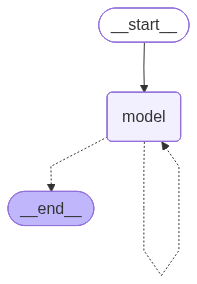

In [28]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain_groq import ChatGroq

@dataclass
class Movieinfo:
    """ Information of the movie"""
    title:str
    director:str
    year:int
    rating:float

llm = ChatGroq(model="openai/gpt-oss-120b")

agents = create_agent(
    model = llm,
    response_format= Movieinfo
)

agents

In [29]:
result = agents.invoke({
    "messages":[{"role":"user","content":"tell about the movie titanic"}]
})
result

{'messages': [HumanMessage(content='tell about the movie titanic', additional_kwargs={}, response_metadata={}, id='85b97a45-8bd0-416d-a870-67d52d152aed'),
  AIMessage(content='{"title":"Titanic","director":"James Cameron","year":1997,"rating":7.8}', additional_kwargs={'reasoning_content': 'The user asks: "tell about the movie titanic". The system expects a JSON object conforming to the Movieinfo schema: fields director, rating, title, year, all required. Must output only final JSON object. Need to provide info about Titanic. Provide director: James Cameron, rating maybe 7.8? Use typical rating (IMDb). Year 1997. Title "Titanic". Provide rating as number. Must be compact JSON (no spaces?). "compact JSON formatting" meaning no unnecessary whitespace. Provide like {"title":"Titanic","director":"James Cameron","year":1997,"rating":7.8}. Ensure order? Not required but okay. Ensure it\'s valid JSON. Output only JSON.'}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tok

In [30]:
result["structured_response"]

Movieinfo(title='Titanic', director='James Cameron', year=1997, rating=7.8)